# 🍷 Wine Reviews — Exploratory Data Analysis

**Course:** EDA (Exploratory Data Analysis)  
**Instructor:** Ali Hassan Sherazi  
**Due Date:** June 5, 2026  
**Dashboard:** [Live Streamlit App](https://wine-reviews-dashboard-ct2sfxnnykfe8hrvgyurtv.streamlit.app/)

---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dark luxury theme matching the dashboard
plt.rcParams.update({
    'figure.facecolor': '#0B1120',
    'axes.facecolor': '#131B2E',
    'axes.edgecolor': '#C9A84C',
    'axes.labelcolor': '#E8E6E1',
    'text.color': '#E8E6E1',
    'xtick.color': '#E8E6E1',
    'ytick.color': '#E8E6E1',
    'grid.color': '#1E2A3A',
    'figure.figsize': (12, 6)
})

GOLD = '#C9A84C'
TEAL = '#2A6B5E'
NAVY = '#0B1120'

print('✅ Setup complete')

✅ Setup complete


---
## 2. Data Loading & Merging

In [2]:
df1 = pd.read_csv('../data/winemag-data_first150k.csv', index_col=0)
df2 = pd.read_csv('../data/winemag-data-130k-v2.csv', index_col=0)

print(f'Dataset 1 (150k): {df1.shape[0]:,} rows, {df1.shape[1]} columns')
print(f'Dataset 2 (130k): {df2.shape[0]:,} rows, {df2.shape[1]} columns')
print(f'\nExtra columns in 130k-v2: {set(df2.columns) - set(df1.columns)}')

Dataset 1 (150k): 150,930 rows, 10 columns
Dataset 2 (130k): 129,971 rows, 13 columns

Extra columns in 130k-v2: {'taster_twitter_handle', 'title', 'taster_name'}


In [3]:
# Merge & deduplicate
df = pd.concat([df1, df2], ignore_index=True, sort=False)
df = df.drop_duplicates()
print(f'Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

Merged dataset: 217,839 rows, 13 columns


---
## 3. Data Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 217839 entries, 0 to 280900
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                217777 non-null  str    
 1   description            217839 non-null  str    
 2   designation            153398 non-null  str    
 3   points                 217839 non-null  int64  
 4   price                  200724 non-null  float64
 5   province               217777 non-null  str    
 6   region_1               182347 non-null  str    
 7   region_2               86260 non-null   str    
 8   variety                217838 non-null  str    
 9   winery                 217839 non-null  str    
 10  taster_name            95071 non-null   str    
 11  taster_twitter_handle  90542 non-null   str    
 12  title                  119988 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 95.6 MB


In [5]:
df.describe()

,points,price
count,217839.000000,200724.000000
mean,88.224152,34.749542
std,3.159017,40.207151
min,80.000000,4.000000
25%,86.000000,16.000000
50%,88.000000,25.000000
75%,90.000000,40.000000
max,100.000000,3300.000000


In [6]:
df.head(10)

,country,description,designation,points,price,province,region_1,region_2,variety,winery,taster_name,taster_twitter_handle,title
0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,NaN,NaN,NaN
1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,NaN,NaN,NaN
2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,NaN,NaN,NaN
3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,NaN,NaN,NaN
4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,NaN,NaN,NaN
5,Spain,"Deep, dense and pure from the opening bell, th...",Numanthia,95,73.0,Northern Spain,Toro,NaN,Tinta de Toro,Numanthia,NaN,NaN,NaN
6,Spain,Slightly gritty black-fruit aromas include a s...,San Román,95,65.0,Northern Spain,Toro,NaN,Tinta de Toro,Maurodos,NaN,NaN,NaN
7,Spain,Lush cedary black-fruit aromas are luxe and of...,Carodorum Único Crianza,95,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,NaN,NaN,NaN
8,US,This re-named vineyard was formerly bottled as...,Silice,95,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström,NaN,NaN,NaN
9,US,The producer sources from two blocks of the vi...,Gap's Crown Vineyard,95,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm,NaN,NaN,NaN


---
## 4. Missing Values Analysis

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)
print(f'\nTotal cells with missing values: {missing.sum():,}')

                        Count  Percentage
region_2               131579       60.40
taster_twitter_handle  127297       58.44
taster_name            122768       56.36
title                   97851       44.92
designation             64441       29.58
region_1                35492       16.29
price                   17115        7.86
country                    62        0.03
province                   62        0.03
variety                     1        0.00

Total cells with missing values: 596,668


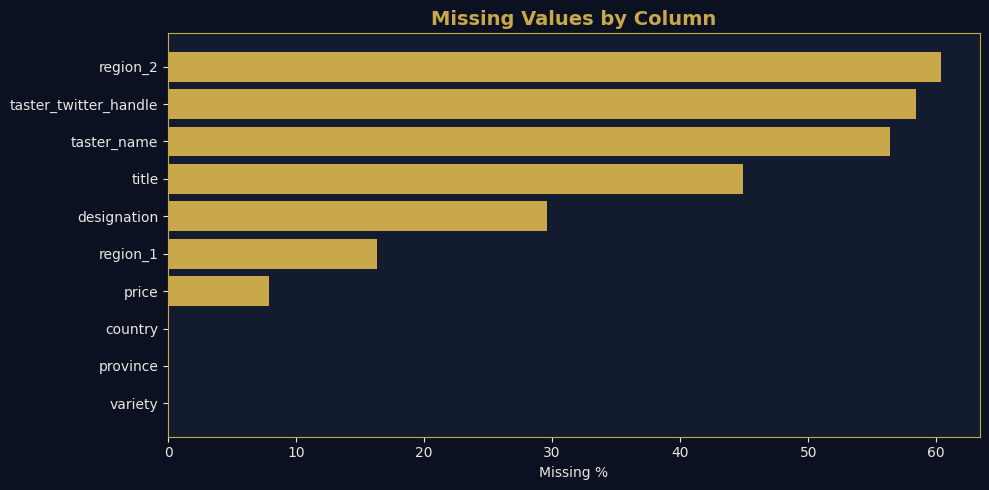

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentage'], color=GOLD, edgecolor='none')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', color=GOLD, fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Key Statistics

In [9]:
print(f"Total Reviews:    {len(df):,}")
print(f"Countries:        {df['country'].nunique()}")
print(f"Varieties:        {df['variety'].nunique()}")
print(f"Wineries:         {df['winery'].nunique()}")
print(f"Price Range:      ${df['price'].min():.0f} — ${df['price'].max():.0f}")
print(f"Avg Price:        ${df['price'].mean():.2f}")
print(f"Points Range:     {df['points'].min()} — {df['points'].max()}")
print(f"Avg Points:       {df['points'].mean():.2f}")

Total Reviews:    217,839
Countries:        50
Varieties:        756
Wineries:         19186
Price Range:      $4 — $3300
Avg Price:        $34.75
Points Range:     80 — 100
Avg Points:       88.22


---
## 6. Chart 1 & 2 — Points Distribution & Price Distribution

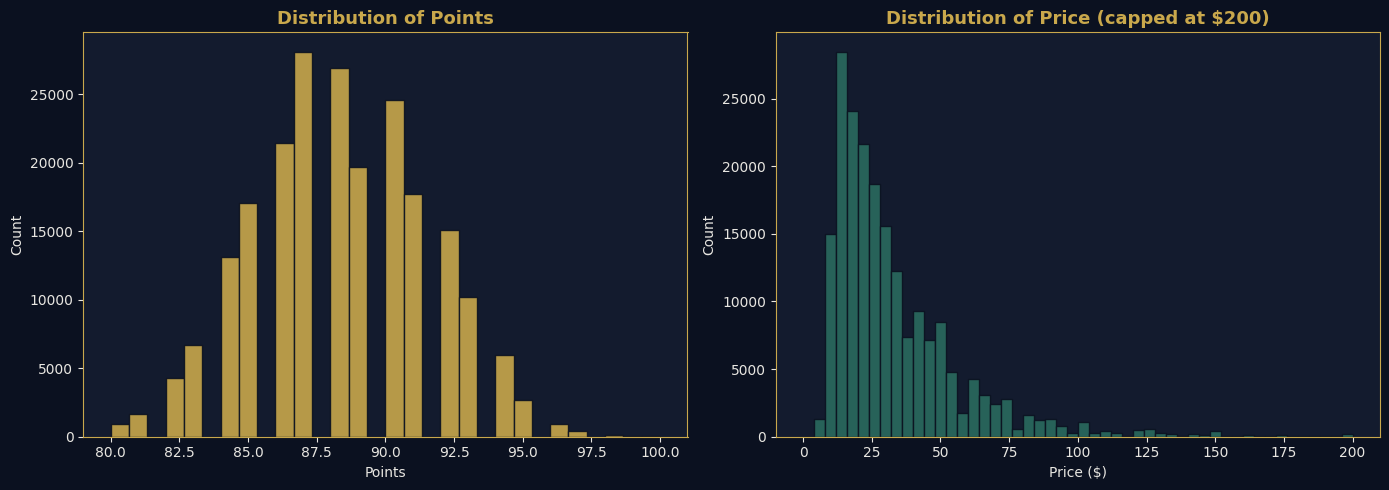

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Points Distribution
axes[0].hist(df['points'].dropna(), bins=30, color=GOLD, edgecolor=NAVY, alpha=0.9)
axes[0].set_title('Distribution of Points', color=GOLD, fontsize=13, fontweight='bold')
axes[0].set_xlabel('Points')
axes[0].set_ylabel('Count')

# Price Distribution
axes[1].hist(df['price'].dropna(), bins=50, color=TEAL, edgecolor=NAVY, alpha=0.9, range=(0, 200))
axes[1].set_title('Distribution of Price (capped at $200)', color=GOLD, fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 7. Chart 3 & 4 — Top 10 Countries & Top 10 Varieties

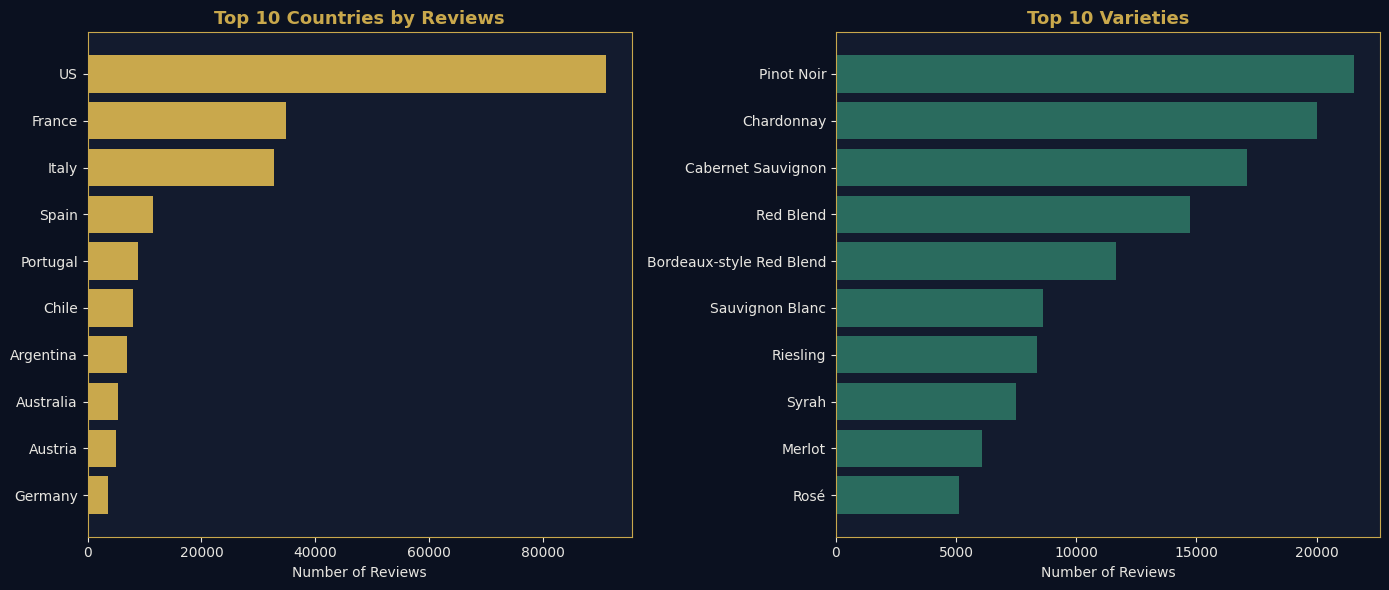

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 Countries
top_countries = df['country'].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=GOLD, edgecolor='none')
axes[0].set_title('Top 10 Countries by Reviews', color=GOLD, fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')

# Top 10 Varieties
top_varieties = df['variety'].value_counts().head(10)
axes[1].barh(top_varieties.index[::-1], top_varieties.values[::-1], color=TEAL, edgecolor='none')
axes[1].set_title('Top 10 Varieties', color=GOLD, fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

---
## 8. Chart 5 — Price vs Points (Scatter)

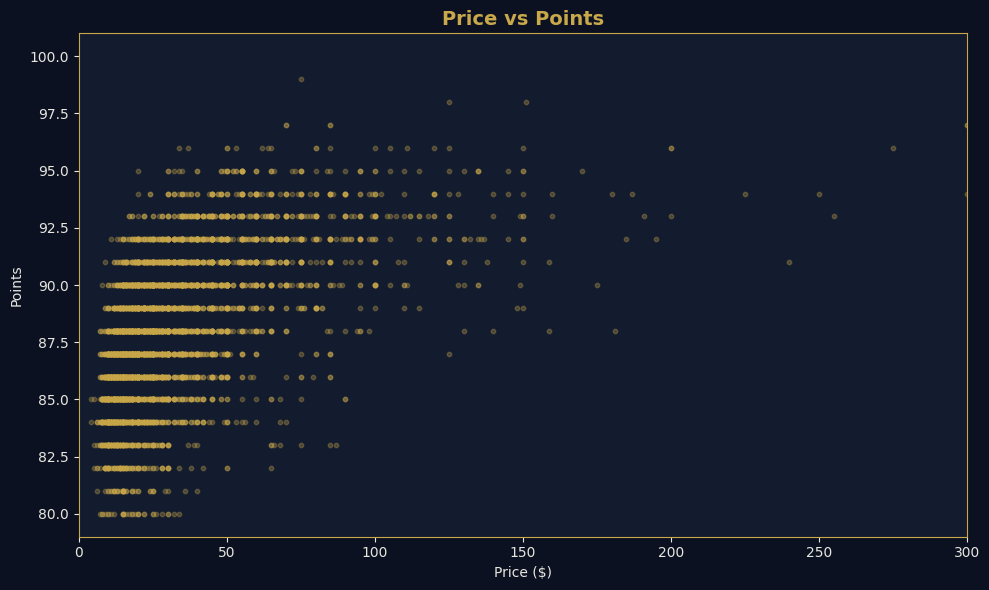

In [12]:
sample = df.dropna(subset=['points', 'price']).sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['price'], sample['points'], alpha=0.3, s=10, color=GOLD)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Points')
ax.set_title('Price vs Points', color=GOLD, fontsize=14, fontweight='bold')
ax.set_xlim(0, 300)
plt.tight_layout()
plt.show()

---
## 9. Chart 6 — Average Points by Country (Top 15)

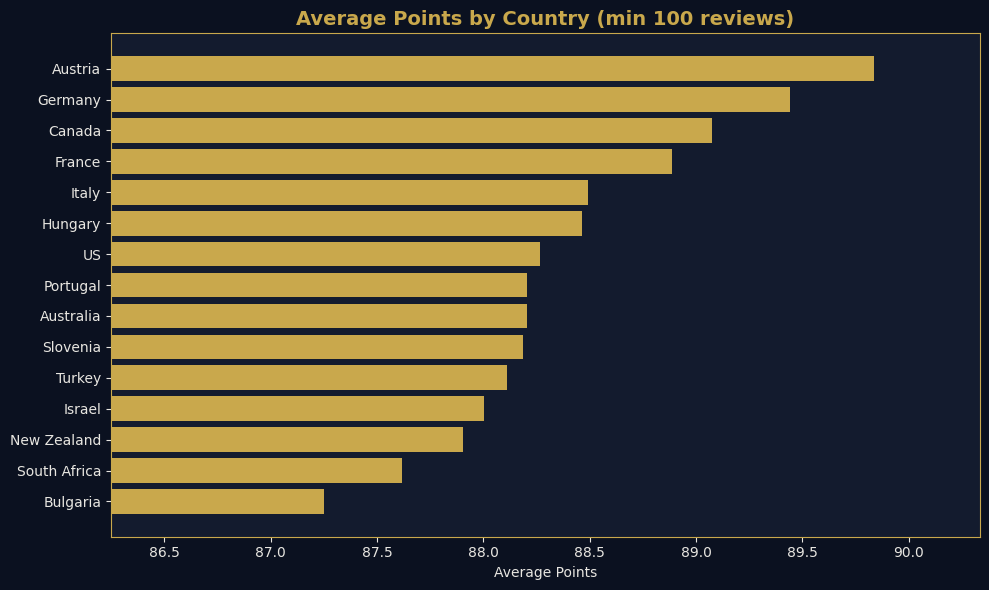

In [13]:
top15 = df.groupby('country').filter(lambda x: len(x) >= 100)
avg_points = top15.groupby('country')['points'].mean().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(avg_points.index, avg_points.values, color=GOLD, edgecolor='none')
ax.set_xlabel('Average Points')
ax.set_title('Average Points by Country (min 100 reviews)', color=GOLD, fontsize=14, fontweight='bold')
ax.set_xlim(avg_points.min() - 1, avg_points.max() + 0.5)
plt.tight_layout()
plt.show()

---
## 10. Chart 7 — Average Price by Country (Top 15)

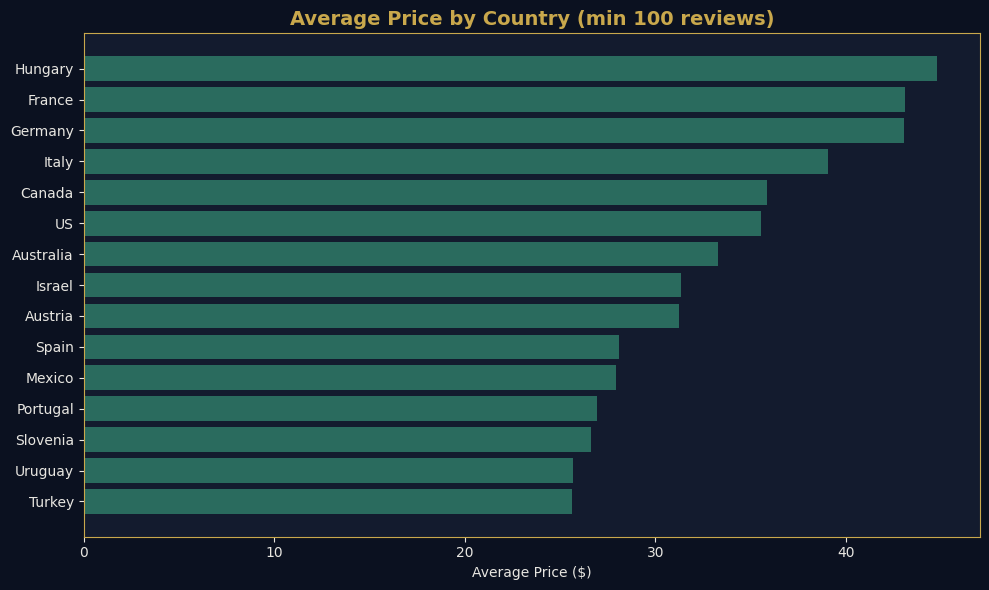

In [14]:
avg_price = top15.groupby('country')['price'].mean().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(avg_price.index, avg_price.values, color=TEAL, edgecolor='none')
ax.set_xlabel('Average Price ($)')
ax.set_title('Average Price by Country (min 100 reviews)', color=GOLD, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Chart 8 — Correlation Heatmap

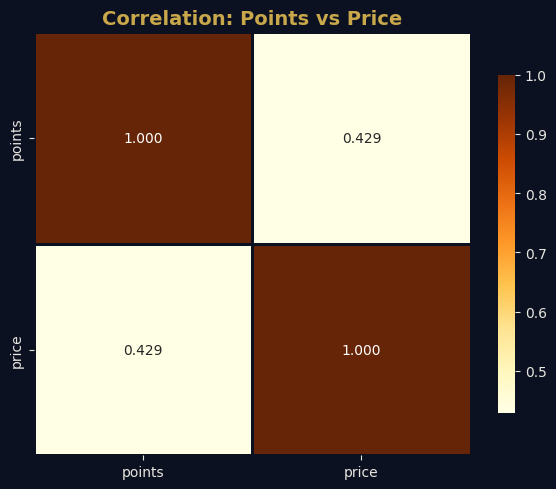

In [15]:
corr = df[['points', 'price']].dropna().corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='YlOrBr', fmt='.3f', ax=ax,
            linewidths=2, linecolor=NAVY, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation: Points vs Price', color=GOLD, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Chart 9 — Points by Top Varieties (Box Plot)

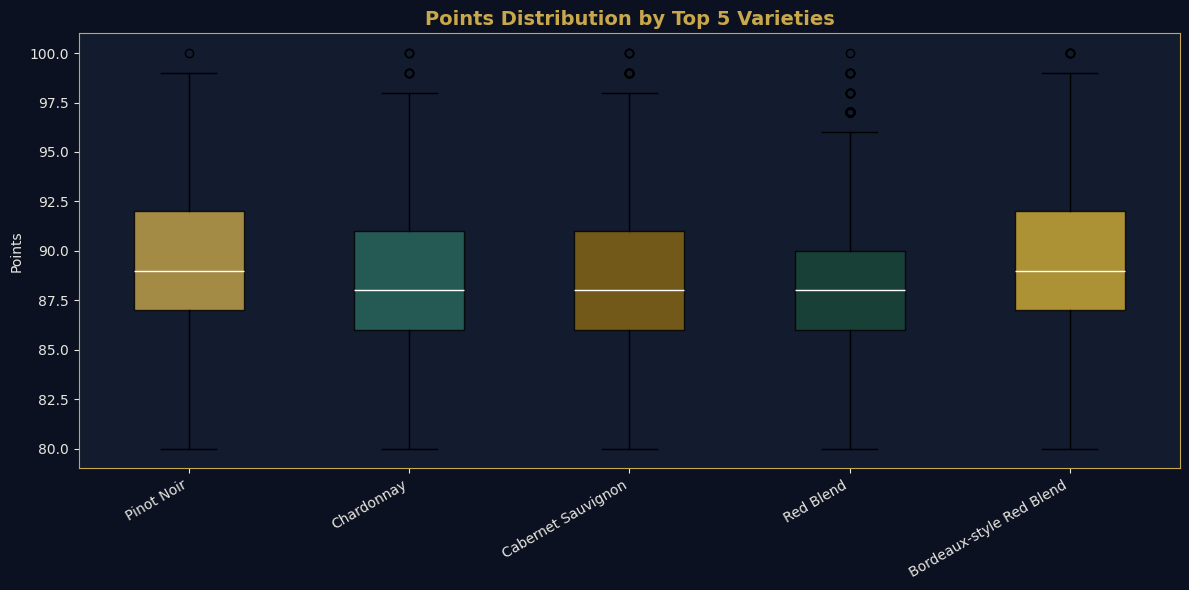

In [16]:
top5_var = df['variety'].value_counts().head(5).index
df_top5 = df[df['variety'].isin(top5_var)]

fig, ax = plt.subplots(figsize=(12, 6))
colors = [GOLD, TEAL, '#8B6914', '#1A4A3A', '#D4AF37']
bp = ax.boxplot([df_top5[df_top5['variety']==v]['points'].dropna() for v in top5_var],
                labels=top5_var, patch_artist=True, medianprops={'color': 'white'})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Points')
ax.set_title('Points Distribution by Top 5 Varieties', color=GOLD, fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 13. Chart 10 — Reviews by Province (Top 10, US)

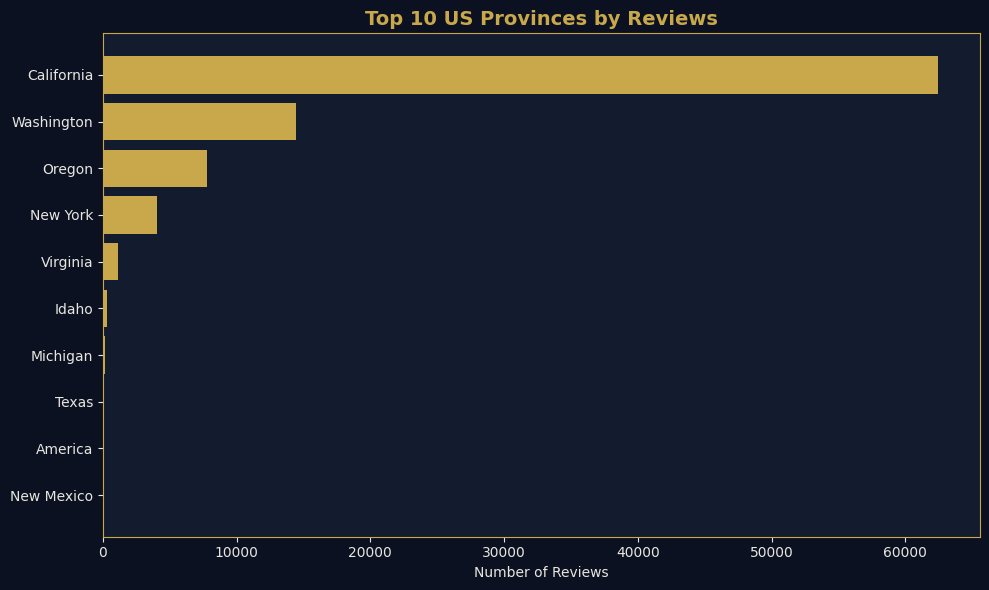

In [17]:
us_df = df[df['country'] == 'US']
top_provinces = us_df['province'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_provinces.index[::-1], top_provinces.values[::-1], color=GOLD, edgecolor='none')
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 10 US Provinces by Reviews', color=GOLD, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 14. Insights Summary

| Insight | Detail |
|---------|--------|
| Most reviewed country | US dominates the dataset |
| Price-Points correlation | Positive but moderate (~0.4) |
| Most common variety | Pinot Noir, Chardonnay lead |
| Price outliers | Some wines exceed $2,000 |
| Points distribution | Concentrated around 85-90 |
| Missing data | Price & designation have highest missing % |

---
## 15. Live Dashboard

The interactive Streamlit dashboard with filters and all 10 charts is deployed here:

**🔗 https://wine-reviews-dashboard-ct2sfxnnykfe8hrvgyurtv.streamlit.app/**

In [18]:
# Generate clickable link to the live dashboard
from IPython.display import display, HTML

dashboard_url = 'https://wine-reviews-dashboard-ct2sfxnnykfe8hrvgyurtv.streamlit.app/'

display(HTML(f'''
<div style="background:#131B2E; border:2px solid #C9A84C; border-radius:12px; padding:24px; text-align:center; margin:20px 0;">
    <h2 style="color:#C9A84C; margin:0 0 12px 0;">🍷 Wine Reviews Dashboard</h2>
    <p style="color:#E8E6E1; margin:0 0 16px 0;">Click below to open the live interactive dashboard</p>
    <a href="{dashboard_url}" target="_blank" 
       style="background:#C9A84C; color:#0B1120; padding:12px 32px; border-radius:8px; 
              text-decoration:none; font-weight:bold; font-size:16px;">
        Open Dashboard ↗
    </a>
</div>
'''))

print(f'\n📎 Dashboard URL: {dashboard_url}')


📎 Dashboard URL: https://wine-reviews-dashboard-ct2sfxnnykfe8hrvgyurtv.streamlit.app/
